In [3]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from scipy import stats 
from scipy.stats import norm
from matplotlib.backends.backend_pdf import PdfPages
import argparse
import sys
from matplotlib import rc, rcParams
import matplotlib.ticker as mticker

# global plotting settings
FONTSIZE = 18 #18 standart 24 for three plots in a row

# matplotlib settings
plt.rc("font", family="serif", size=FONTSIZE, serif="Charter")
plt.rc("axes", titlesize=FONTSIZE)
# plt.rc("text.latex", preamble=r"\usepackage{amsmath}\usepackage[bitstream-charter]{mathdesign}")
plt.rc(
    "text.latex",
    preamble=r"""
\usepackage{amsmath}
\usepackage[bitstream-charter]{mathdesign}
\DeclareSymbolFont{usualmathcal}{OMS}{cmsy}{m}{n}
\DeclareSymbolFontAlphabet{\mathcal}{usualmathcal}
"""
)
plt.rc("text", usetex=True)
# rc('xtick', labelsize=FONTSIZE)
rc('ytick', labelsize=FONTSIZE)

rcParams["errorbar.capsize"] = 7.0
rcParams['legend.frameon']=False
rcParams['legend.handlelength']=1.5


In [32]:
def plot_fig2(x_star, mean_curve, lo68, hi68, lo95, hi95, xt3_true_star=None, outpath=None):
    fig, axes = plt.subplots(2, 1, figsize=(7, 8))
    ax = axes[0]
    ax.fill_between(x_star, lo95, hi95, alpha=0.2, color='C0', label="$95\%$ band")
    # ax.scatter(x_star, hi95, alpha=0.2, color='C0')
    ax.fill_between(x_star, lo68, hi68, alpha=0.4, color='C1', label="$68\%$ band")
    # ax.scatter(x_star, hi68, alpha=0.4, color='C1')
    ax.plot(x_star, mean_curve, lw=2, color='C1', label="prediction")
    if xt3_true_star is not None:
        ax.plot(x_star, xt3_true_star, lw=2, linestyle='dashed', color='C2', label="NNPDF")
    ax.set_ylabel(r"$xT_3(x)$")
    ax.set_xlim([0, 1.])
    ax.set_ylim([-2.0, 2.0])
    ax.legend(frameon=False, loc='upper right', ncol=2)
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    ax.fill_between(x_star, lo95, hi95, alpha=0.2, color='C0', label="$95\%$ band")
    # ax.scatter(x_star, hi95, alpha=0.2, color='C0')
    ax.fill_between(x_star, lo68, hi68, alpha=0.4, color='C1', label="$68\%$ band")
    # ax.scatter(x_star, hi68, alpha=0.4, color='C1')
    ax.plot(x_star, mean_curve, lw=2, color='C1', label="prediction")
    if xt3_true_star is not None:
        ax.plot(x_star, xt3_true_star, lw=2, linestyle='dashed', color='C2', label="NNPDF")
    ax.set_xscale("log")
    ax.set_xlim([1e-3, 1.0])
    ax.set_ylim([-2.0, 2.0])
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$xT_3(x)$")
    ax.legend(frameon=False, loc='upper right', ncol=2)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    # return fig

In [3]:
# load arrays
replicas = np.load("../results/gibbs_kernel/fstar_replicas.npy")
means    = np.load("../results/gibbs_kernel/fstar_means.npy")

npz = np.load("../results/gibbs_kernel/fstar_posterior_summary.npz")

true = npz["xt3_true_star"]
# vars_f = npz["vars_fstar_replicas"]
print(npz.keys)
xgrid = npz["x_star"]

mean_curve = means.mean(axis=0)
lo68, hi68 = np.percentile(replicas, [16, 84], axis=0)
lo95, hi95 = np.percentile(replicas, [2.5, 97.5], axis=0)

# gp_sd    = np.sqrt(vars_f.mean(axis=0))          # GP conditional term
theta_sd = np.sqrt(means.var(axis=0, ddof=1))    # hyperparameter term

<bound method Mapping.keys of NpzFile '../results/gibbs_kernel/fstar_posterior_summary.npz' with keys: x_star, mean_curve, lo68, hi68, lo95...>


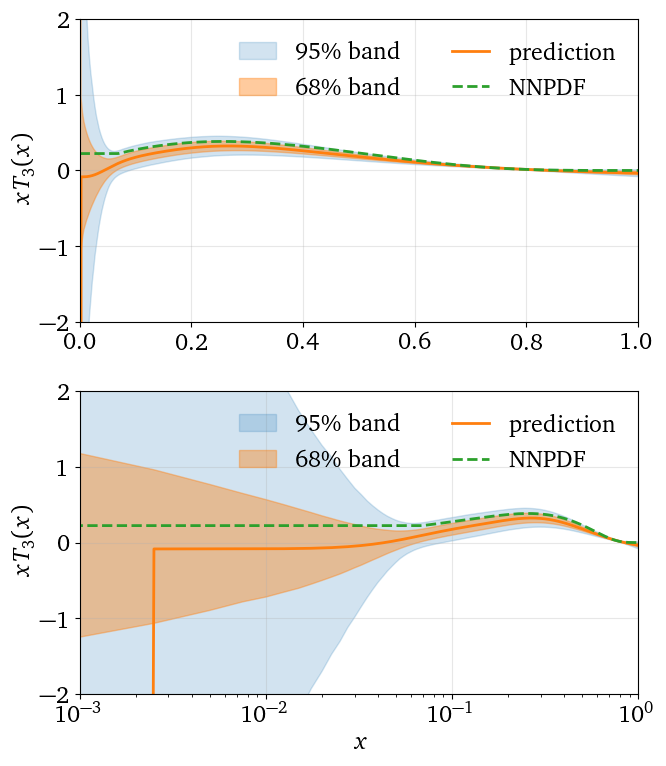

In [33]:
plot_fig2(xgrid, mean_curve, lo68, hi68, lo95, hi95, xt3_true_star=true)



# plot_fig2(xgrid, mean_curve, lo68, hi68,  lo95=(mean_curve - 1.96 * theta_sd), hi95=(mean_curve + 1.96 * theta_sd), xt3_true_star=true)

# test loss values


In [ ]:
data = np.load("../results/nn/test_T3Beta/nn_uncertainty_summary.npz")



KeyError: 'loss_history is not a file in the archive'